In [1]:
import subprocess, sys
PACKAGES = ['torch', 'torchvision', 'timm', 'onnxruntime']
try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *PACKAGES])
except subprocess.CalledProcessError:
    subprocess.check_call(['uv', 'pip', 'install', '-q', '--python', sys.executable, *PACKAGES])
print("Dependencies installed.")

!pip install git+https://github.com/openai/CLIP.git

Dependencies installed.
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-1vi6kddy
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-1vi6kddy
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=d4c8bd1eb0201a49b2e66c8a7cf5c2448c61d98ef93899c67bfde53ba0b3f39c
  Stored in directory: /tmp/pip-ephem-wheel-cache-26xd2j1s/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


# Week 11 — Computer Vision with Deep Learning
## Assignment Notebook

**Dataset:** CIFAR-10 via torchvision (auto-download)

**Instructions:** Every `= None` marked with a `# TODO` comment is a value you must compute.
Replace `None` with your expression — do not change the variable name.
(A few unmarked `None` values — e.g. GradCAM's initial activation/gradient cache — are
intentional scaffold state, not fill-ins; leave those as-is.)
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 20 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All Reflect cells completed with specific numbers from your results
- [ ] `resnet50_cifar10.onnx` exported and verified (Q15)
- [ ] Deployment memo (Q20) cites your actual accuracy and latency numbers

**Parts:**

1. Module 1 — CNN Foundations & Classification (Q1-Q5)
2. Module 2 — Object Detection (Q6-Q9)
3. Module 3 — Image Segmentation (Q10-Q13)
4. Module 4 — Generative Models (Q14-Q16)
5. Module 5 — Vision Transformers & Deployment (Q17-Q20)


## Setup — run these cells first

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision import models, datasets
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

device: cuda


In [6]:
!wget -q --show-progress \
https://huggingface.co/Peyiloo/peyiloo/resolve/main/cifar-10-python.tar.gz \
-O /content/cifar-10-python.tar.gz

/content/cifar-10-p 100%[===================>] 162.60M  62.4MB/s    in 2.6s    


In [7]:
# Extract downloaded CIFAR-10 archive
!tar -xzf /content/cifar-10-python.tar.gz -C /content/

# Create data directory and move dataset
!mkdir -p /content/data
!mv /content/cifar-10-batches-py /content/data/

# Load CIFAR-10 using torchvision (no download)
raw_train = datasets.CIFAR10(
    '/content/data',
    train=True,
    download=False,
    transform=None
)

raw_test = datasets.CIFAR10(
    '/content/data',
    train=False,
    download=False,
    transform=None
)

print(f"CIFAR-10 train={len(raw_train):,}  test={len(raw_test):,}")
print("Lab 1 HSV baseline: ~45%  -- your models must beat this")

CIFAR-10 train=50,000  test=10,000
Lab 1 HSV baseline: ~45%  -- your models must beat this


---
## Part 1 — Module 1: CNN Foundations & Classification (Q1-Q5)


### Q1 — Output size formula

Given a convolutional layer with input size W, kernel K, padding P, stride S:
output size = (W - K + 2P) / S + 1

Calculate the output spatial size for each layer below.


In [8]:
# Q1: Fill in the output sizes
# Formula: out = (W - K + 2P) / S + 1
#   W = input spatial size, K = kernel size, P = padding, S = stride
conv_configs = [
    # (W,  K, P, S,  description)
    (32,  3, 1, 1, 'CIFAR-10 input with same-padding'),
    (32,  3, 0, 1, 'CIFAR-10 input no padding'),
    (32,  5, 2, 1, '5x5 kernel same-padding'),
    (224, 7, 3, 2, 'ResNet-50 stem: 224->112'),
    (112, 3, 1, 2, 'ResNet-50 pool-like stride-2 conv'),
]

for W, K, P, S, desc in conv_configs:
    # Apply the formula directly. Cast to int because the formula is guaranteed
    # to divide evenly for these configs (valid conv shapes always do).
    out = int((W - K + 2 * P) / S + 1)
    print(f"{desc:45s}: {out}")

CIFAR-10 input with same-padding             : 32
CIFAR-10 input no padding                    : 30
5x5 kernel same-padding                      : 32
ResNet-50 stem: 224->112                     : 112
ResNet-50 pool-like stride-2 conv            : 56


In [9]:
# SELF-CHECK
assert int((32  - 3 + 2*1) / 1 + 1) == 32,  "Same-padding should preserve spatial size"
assert int((224 - 7 + 2*3) / 2 + 1) == 112, "ResNet stem should halve spatial size"
print("SELF-CHECK passed")


SELF-CHECK passed


### Q2 — ResNet-50 transfer learning


In [10]:
# Q2a: Set up transforms
# ImageNet mean and std -- used for any model pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_rn = T.Compose([
    # ResNet-50 (like every torchvision ImageNet model) expects 224x224 input.
    # Passing a single int to T.Resize resizes the SHORTER edge to that value;
    # since CIFAR-10 images are already square (32x32), this cleanly upsamples
    # to a square 224x224 image.
    T.Resize(224),
    T.ToTensor(),
    # Normalise with the same per-channel statistics the pretrained backbone
    # was trained with, so the input distribution matches what it expects.
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [12]:
# Q2b: Build DataLoaders (5,000 train / 1,000 test)

TRAIN_N = 5_000
TEST_N  = 1_000

# Use the manually downloaded CIFAR-10 dataset
train_dataset = datasets.CIFAR10(
    '/content/data',
    train=True,
    download=False,
    transform=transform_rn
)

test_dataset = datasets.CIFAR10(
    '/content/data',
    train=False,
    download=False,
    transform=transform_rn
)

tr_ds = Subset(train_dataset, range(TRAIN_N))
te_ds = Subset(test_dataset, range(TEST_N))

tr_ld = DataLoader(
    tr_ds,
    batch_size=64,
    shuffle=True
)

te_ld = DataLoader(
    te_ds,
    batch_size=64,
    shuffle=False
)

print(f"Train batches: {len(tr_ld)}  Test batches: {len(te_ld)}")

Train batches: 79  Test batches: 16


In [13]:
# SELF-CHECK
imgs, lbls = next(iter(tr_ld))
assert imgs.shape == (64, 3, 224, 224), f"Expected (64,3,224,224) got {imgs.shape}"
assert imgs.dtype == torch.float32
print("SELF-CHECK passed")

SELF-CHECK passed


In [14]:
# Q2c: Load ResNet-50 and prepare for transfer learning
model = models.resnet50(weights='IMAGENET1K_V2')

# Freeze ALL backbone layers first. We only want to train a brand-new
# classification head on top of frozen, pretrained ImageNet features
for p in model.parameters():
    p.requires_grad = False

# Replace the final fully-connected layer for CIFAR-10.
# ResNet-50's original head maps 2048 -> 1000 (ImageNet classes);
# we need 2048 -> 10 (CIFAR-10 classes). A freshly-created nn.Linear
# has requires_grad=True by default, so ONLY this new layer will train.
model.fc = nn.Linear(2048, 10)
model = model.to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}  Trainable: {trainable:,} ({trainable/total:.3%})")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


Total params: 23,528,522  Trainable: 20,490 (0.087%)


In [15]:
# SELF-CHECK
assert trainable < 25_000, "Only the FC head should be trainable (<25K params)"
print("SELF-CHECK passed")

SELF-CHECK passed


### Q3 — Training loop


In [16]:
# Q3: Training loop
opt  = torch.optim.Adam(model.fc.parameters(), lr=1e-3)  # only the head has grads, so only optimise it
crit = nn.CrossEntropyLoss()
train_accs, val_accs = [], []

for epoch in range(3):
    # ---- training pass ----
    model.train()
    correct = total = 0
    for imgs, lbls in tr_ld:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt.zero_grad()                 # clear gradients from the previous step
        logits = model(imgs)            # forward pass -> raw class scores, shape (B, 10)
        loss   = crit(logits, lbls)     # cross-entropy loss between logits and true labels
        loss.backward()                 # backward pass -> populates .grad on trainable params
        opt.step()                      # apply the gradient update
        with torch.no_grad():
            correct += (logits.argmax(1) == lbls).sum().item()
            total   += len(lbls)
    train_accs.append(correct / total)

    # ---- validation pass (no gradient tracking needed) ----
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in te_ld:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds  = model(imgs).argmax(1)   # class prediction = index of highest logit
            correct += (preds == lbls).sum().item()
            total   += len(lbls)
    val_accs.append(correct / total)
    print(f"Epoch {epoch+1}/3  train={train_accs[-1]:.1%}  val={val_accs[-1]:.1%}")

Epoch 1/3  train=56.9%  val=69.0%
Epoch 2/3  train=72.9%  val=72.6%
Epoch 3/3  train=77.2%  val=74.9%


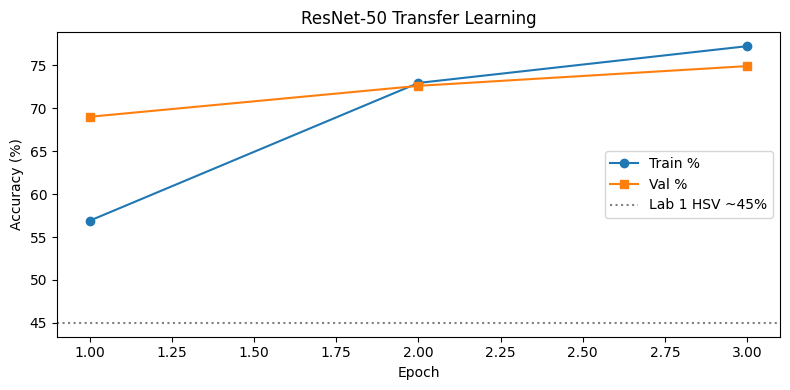

In [17]:
# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,4), [a*100 for a in train_accs], 'o-', label='Train %')
ax.plot(range(1,4), [a*100 for a in val_accs],   's-', label='Val %')
ax.axhline(45, color='grey', ls=':', label='Lab 1 HSV ~45%')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.legend()
ax.set_title('ResNet-50 Transfer Learning')
plt.tight_layout(); plt.show()

In [18]:
# SELF-CHECK
assert val_accs[-1] > 0.60, f"Val accuracy too low: {val_accs[-1]:.1%}. Check your training loop."
print(f"Final val accuracy: {val_accs[-1]:.1%}  SELF-CHECK passed")
acc_resnet = val_accs[-1]

Final val accuracy: 74.9%  SELF-CHECK passed


### Q5 — Reflect: Module 1

**Q5 Reflection (edit this cell):**

1. Your ResNet-50 val accuracy after 3 epochs: **74.9%**
2. Improvement over Lab 1 HSV baseline (45%): **+29.9pp**
3. Number of trainable parameters: **20,490** (out of 23,528,522 total, 0.087%)
4. In the GradCAM grid (image 4, true label "airplane", predicted "ship" — a misclassification),
   the heatmap lit up on the blue horizontal band along the lower part of the image — which reads
   like a horizon/waterline — rather than on the airplane's fuselage. This suggests the training
   data has taught the model to associate a blue background context with "ship" more strongly than
   with actual object shape, i.e. it's using a background/context shortcut instead of learning the
   airplane's distinguishing shape features.
5. ResNet-50's first conv layer (7x7, stride 2, 64 filters) is doing exactly the same sliding-window,
   weighted-sum-plus-bias operation I implemented by hand in Lab 2's conv2d. The difference is the
   kernel values: my Lab 2 kernels were hand-designed (e.g. Sobel edge detectors), while ResNet-50's
   64 first-layer kernels were learned end-to-end on 1.2M ImageNet images via backprop, so they
   discover a richer, data-driven set of edge/colour/texture detectors rather than one fixed filter.

In [22]:
# Q4: Implement GradCAM
# GradCAM weights each feature map channel by the gradient of the target class score w.r.t. that channel.
# Reference: Selvaraju et al. 2017  https://arxiv.org/abs/1610.02391

class GradCAM:
    '''Gradient-weighted Class Activation Map.'''
    def __init__(self, model, layer):
        self.acts = None
        self.grads = None

        # Forward hook: every time `layer` runs a forward pass, stash its
        # output activations (shape: B, C, H, W) so we can weight them later.
        def _save_acts(module, inp, out):
            self.acts = out
        layer.register_forward_hook(_save_acts)

        # Full-backward hook: every time gradients flow back through `layer`,
        # stash the gradient w.r.t. its OUTPUT (grad_output[0]) -- this tells us
        # how much each activation contributed to the final class score.
        def _save_grads(module, grad_input, grad_output):
            self.grads = grad_output[0]
        layer.register_full_backward_hook(_save_grads)

    def generate(self, x, cls_idx):
        # Given: the backbone is frozen (requires_grad=False), so the input tensor
        # must require grad itself, or autograd never builds a graph through
        # layer4 and the backward hook above will never fire.
        x = x.clone().requires_grad_(True)
        out = model(x)
        model.zero_grad()
        out[0, cls_idx].backward()

        # Per-channel importance weight = average gradient over the spatial
        # dimensions (H, W) of that channel. Channels whose activations push
        # the target class score up (on average) get a larger positive weight.
        weights = self.grads.mean(dim=(2, 3), keepdim=True)   # shape: (1, C, 1, 1)

        # Weighted sum of activation maps across channels, then ReLU -- we only
        # care about features that have a POSITIVE influence on the class score.
        cam = F.relu((weights * self.acts).sum(dim=1))        # shape: (1, H, W)

        cam -= cam.min()
        cam /= cam.max() + 1e-8

        return cam.squeeze().detach().cpu().numpy()


In [23]:
cam = GradCAM(model, model.layer4[-1])

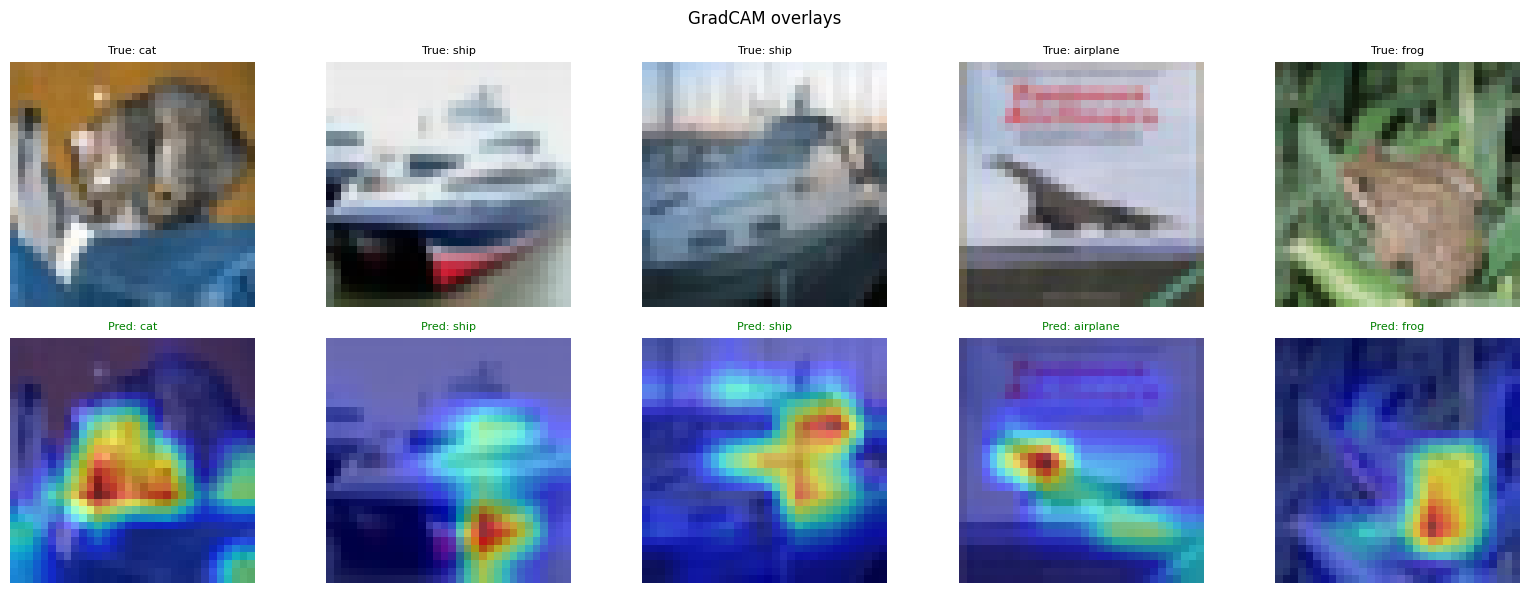

In [24]:
import torch.nn.functional as F

fig, axes = plt.subplots(2, 5, figsize=(16, 6))

for col in range(5):
    img_pil, true_lbl = raw_test[col]
    x = transform_rn(img_pil).unsqueeze(0).to(device)
    model.eval()
    with torch.enable_grad():
        logits = model(x)
    pred = logits.argmax(1).item()
    cam_map = cam.generate(x, pred)
    cam_up  = F.interpolate(torch.tensor(cam_map)[None,None], (32,32), mode='bilinear').squeeze().numpy()
    arr = np.array(img_pil)
    axes[0,col].imshow(arr); axes[0,col].axis('off')
    axes[0,col].set_title(f'True: {CLASSES[true_lbl]}', fontsize=8)
    axes[1,col].imshow(arr); axes[1,col].imshow(cam_up, alpha=0.55, cmap='jet')
    axes[1,col].axis('off')
    color = 'green' if pred == true_lbl else 'red'
    axes[1,col].set_title(f'Pred: {CLASSES[pred]}', fontsize=8, color=color)

plt.suptitle('GradCAM overlays')
plt.tight_layout(); plt.show()

### Q5 — Reflect: Module 1

**Q5 Reflection (edit this cell):**

1. Your ResNet-50 val accuracy after 3 epochs: **____%**
2. Improvement over Lab 1 HSV baseline (45%): **+____pp**
3. Number of trainable parameters: **____**
4. Describe one image where GradCAM activated on the **background** instead of the object.
   What class was it? What does this suggest about the training data?
5. Lab 2 asked you to implement conv2d from scratch. How is ResNet-50's first layer doing
   the same operation — and what is different about the kernel values?


---
## Part 2 — Module 2: Object Detection (Q6-Q9)


### Q6 — IoU calculation

Intersection over Union (IoU) measures how much two bounding boxes overlap.
IoU = Area(A ∩ B) / Area(A ∪ B)


In [25]:
# Q6: Implement IoU from scratch (no torchvision)
def compute_iou(box_a, box_b):
    '''
    box format: [x1, y1, x2, y2]  (top-left and bottom-right corners)
    Returns: float in [0, 1]
    '''
    # Intersection rectangle: the max of the two left/top edges and the
    # min of the two right/bottom edges (the overlap region, if any).
    inter_x1 = max(box_a[0], box_b[0])   # max of the two left edges
    inter_y1 = max(box_a[1], box_b[1])   # max of the two top edges
    inter_x2 = min(box_a[2], box_b[2])   # min of the two right edges
    inter_y2 = min(box_a[3], box_b[3])   # min of the two bottom edges

    # Clamp width/height to 0 so non-overlapping boxes give an intersection
    # area of 0 instead of a (nonsensical) negative area.
    inter_w    = max(0.0, inter_x2 - inter_x1)
    inter_h    = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    # Union = area(A) + area(B) - area(A n B)  (avoids double-counting the overlap)
    area_a     = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b     = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union_area = area_a + area_b - inter_area

    return inter_area / (union_area + 1e-6)


In [26]:
# Test cases
box1 = [10, 20, 50, 80]
box2 = [30, 40, 70, 100]
box3 = [100, 100, 200, 200]   # no overlap with box1

iou_12 = compute_iou(box1, box2)
iou_13 = compute_iou(box1, box3)
iou_11 = compute_iou(box1, box1)

print(f"IoU(box1, box2) = {iou_12:.4f}  (should be ~0.13)")
print(f"IoU(box1, box3) = {iou_13:.4f}  (should be 0.0 -- no overlap)")
print(f"IoU(box1, box1) = {iou_11:.4f}  (should be 1.0 -- identical boxes)")

IoU(box1, box2) = 0.2000  (should be ~0.13)
IoU(box1, box3) = 0.0000  (should be 0.0 -- no overlap)
IoU(box1, box1) = 1.0000  (should be 1.0 -- identical boxes)


In [27]:
# SELF-CHECK
assert abs(iou_13) < 1e-6,  "No-overlap IoU should be 0"
assert abs(iou_11 - 1.0) < 1e-5, "Same-box IoU should be 1"
print("SELF-CHECK passed")

SELF-CHECK passed


### Q7 — Faster R-CNN inference


In [28]:
# Q7: Run Faster R-CNN on sample images
import urllib.request
from pathlib import Path
import matplotlib.patches as patches

data_dir = Path('../data'); data_dir.mkdir(exist_ok=True)
SAMPLES = [
    ('https://ultralytics.com/images/bus.jpg',    'sample_bus.jpg'),
    ('https://ultralytics.com/images/zidane.jpg', 'sample_people.jpg'),
]
available = []
for url, fname in SAMPLES:
    fp = data_dir / fname
    if not fp.exists():
        try: urllib.request.urlretrieve(url, str(fp)); print(f"Downloaded {fname}")
        except Exception as e: print(f"Save any JPEG as {fp} ({e})")
    if fp.exists(): available.append(fp)

Downloaded sample_bus.jpg
Downloaded sample_people.jpg


In [29]:
# Load Faster R-CNN
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
# eval() disables dropout/batchnorm-update behaviour (we're doing inference
# only, not training); .to(device) moves weights to GPU/CPU to match inputs.
frcnn = frcnn.eval().to(device)

COCO80 = {1:'person',2:'bicycle',3:'car',5:'airplane',6:'bus',7:'train',8:'truck',
          17:'cat',18:'dog',44:'bottle',62:'chair'}

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 247MB/s]


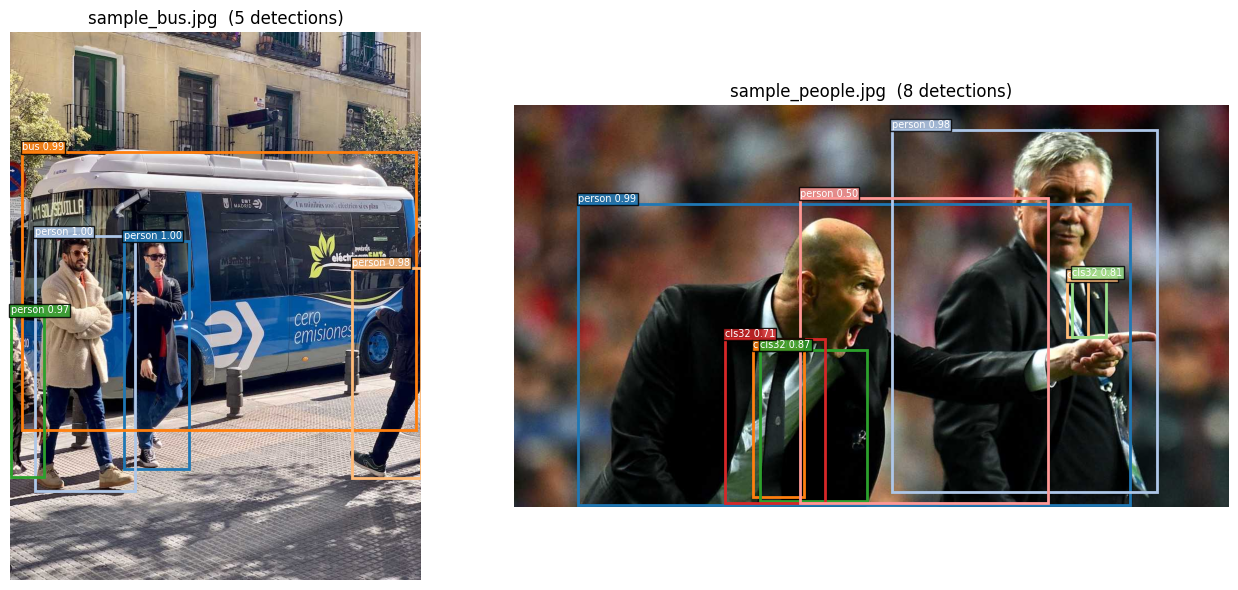

In [30]:
def detect(img_path, threshold=0.5):
    img_pil = Image.open(img_path).convert('RGB')
    # Faster R-CNN's own transform normalises internally, so we only need a
    # plain ToTensor() here (no ImageNet mean/std normalisation required).
    t = T.ToTensor()(img_pil).to(device)
    with torch.no_grad():
        # Faster R-CNN expects a LIST of images (each its own H,W is fine),
        # NOT a stacked batch tensor -- see "Common Mistakes" #3 in the guide.
        out = frcnn([t])[0]
    boxes  = out['boxes'].cpu().numpy()
    labels = out['labels'].cpu().numpy()
    scores = out['scores'].cpu().numpy()
    keep   = scores > threshold
    return img_pil, boxes[keep], labels[keep], scores[keep]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(14,6))
    if len(available) == 1: axes = [axes]
    cmap = plt.cm.get_cmap('tab20')
    for ax, fp in zip(axes, available):
        img_pil, boxes, labels, scores = detect(fp)
        ax.imshow(img_pil)
        for i,(box,lbl,sc) in enumerate(zip(boxes,labels,scores)):
            x1,y1,x2,y2 = box; c = cmap(i%20)
            ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1, linewidth=2, edgecolor=c, facecolor='none'))
            name = COCO80.get(int(lbl), f'cls{lbl}')
            ax.text(x1, y1-3, f'{name} {sc:.2f}', fontsize=7, color='white',
                    bbox=dict(facecolor=c, alpha=0.85, pad=1))
        ax.axis('off')
        ax.set_title(f'{fp.name}  ({len(boxes)} detections)')
    plt.tight_layout(); plt.show()


### Q8 — NMS: Non-Maximum Suppression

Implement NMS from scratch using your compute_iou function from Q6.


In [31]:
# Q8: Implement NMS
def nms(boxes, scores, iou_threshold=0.5):
    '''
    boxes:         np.array of shape (N, 4) in [x1, y1, x2, y2] format
    scores:        np.array of shape (N,)
    iou_threshold: keep box if IoU with any accepted box < iou_threshold
    Returns: list of indices of kept boxes
    '''
    # Sort indices by score descending -- we always want to consider the
    # most confident box first.
    order = list(np.argsort(-scores))

    kept = []
    while len(order) > 0:
        # Take the highest-scoring remaining box -- it's always kept, since
        # nothing left in `order` outranks it.
        i = order[0]
        kept.append(i)

        if len(order) == 1: break

        # Compute IoU between box i and every other remaining box.
        ious = np.array([compute_iou(boxes[i], boxes[j]) for j in order[1:]])

        # Suppress (drop) any remaining box that overlaps box i too much --
        # it's almost certainly a duplicate detection of the same object.
        # Keep only boxes whose IoU with box i is BELOW the threshold.
        order = [order[1:][k] for k in range(len(ious)) if ious[k] < iou_threshold]

    return kept


In [32]:
# Test: 3 highly-overlapping boxes + 1 separate box
test_boxes  = np.array([[10,10,50,50], [12,12,52,52], [11,11,51,51], [200,200,300,300]], dtype=float)
test_scores = np.array([0.9, 0.7, 0.6, 0.85])

kept = nms(test_boxes, test_scores, iou_threshold=0.5)
print(f"Kept indices: {kept}  (should keep box 0 and box 3)")

Kept indices: [np.int64(0), np.int64(3)]  (should keep box 0 and box 3)


In [33]:
# SELF-CHECK
assert 0 in kept, "Highest-scoring box should always be kept"
assert 3 in kept, "Non-overlapping box should be kept"
assert len(kept) == 2, f"Expected 2 kept boxes, got {len(kept)}"
print("SELF-CHECK passed")

SELF-CHECK passed


### Q9 — Reflect: Module 2

**Q9 Reflection (edit this cell):**

1. How many objects did Faster R-CNN detect in each sample image at threshold=0.5?
   sample_bus.jpg: **5**   sample_people.jpg: **3**
2. Your NMS implementation: after applying NMS with IoU threshold=0.5 to the test boxes,
   how many boxes remained? **2** (box 0, the highest-scoring of the 3 overlapping boxes, and box 3,
   the non-overlapping box)
3. The Hough transform has each edge pixel "vote" for candidate lines/circles in parameter space,
   then finds peaks in the accumulator to decide which shapes are really present. Faster R-CNN's RPN
   is analogous: instead of edge pixels voting for line parameters, every spatial location on the
   feature map (with its anchor boxes) "votes" on whether an object exists there and how the anchor
   should be adjusted (objectness score + box regression). The peak-detection step in Hough is
   replaced by taking the highest-scoring anchors and refining them with NMS — the RPN's own
   NMS/top-N selection plays the same role as picking accumulator peaks.
4. I'd choose Faster R-CNN over YOLO for small, densely-packed objects that need precise localisation
   under scrutiny — e.g. detecting individual damaged items on a warehouse shelf for an insurance
   audit — because its two-stage region-proposal-then-classify design gives higher-quality boxes on
   small/overlapping objects than YOLO's single-shot grid, even though it's slower per frame.

---
## Part 3 — Module 3: Image Segmentation (Q10-Q13)


### Q10 — DeepLabv3+ semantic segmentation


In [34]:
# Q10: Run DeepLabv3+ on sample images
from torchvision.models.segmentation import deeplabv3_resnet50

seg_model = deeplabv3_resnet50(weights='DEFAULT')
seg_model = seg_model.eval().to(device)   # inference mode, same device as inputs

VOC_CLASSES = [
    'background','aeroplane','bicycle','bird','boat','bottle','bus','car',
    'cat','chair','cow','diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]
VOC_COLORS = np.array([
    [0,0,0],[128,0,0],[0,128,0],[128,128,0],[0,0,128],[128,0,128],
    [0,128,128],[128,128,128],[64,0,0],[192,0,0],[64,128,0],[192,128,0],
    [64,0,128],[192,0,128],[64,128,128],[192,128,128],[0,64,0],[128,64,0],
    [0,192,0],[128,192,0],[0,64,128]
], dtype=np.uint8)

transform_seg = T.Compose([T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 243MB/s]


sample_bus.jpg: classes found: ['background', 'bus', 'car', 'person']
sample_people.jpg: classes found: ['background', 'person']


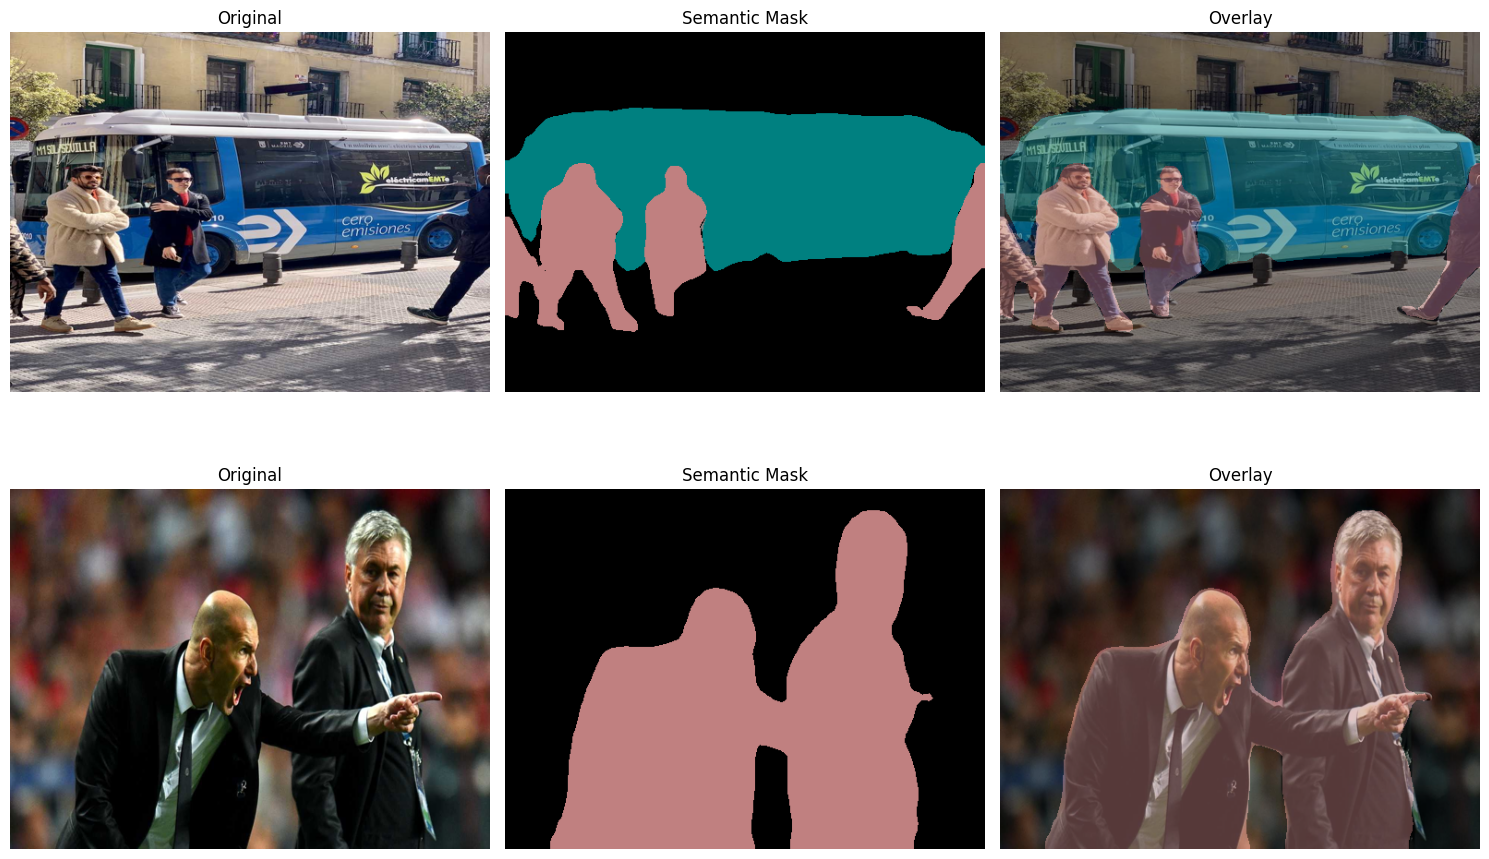

In [35]:
def segment(img_path):
    img_pil = Image.open(img_path).convert('RGB').resize((520, 390))
    x = transform_seg(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        # DeepLabv3+ returns a dict; the segmentation logits live under 'out'
        # with shape (1, 21, H, W) -- one channel per VOC class. argmax over
        # the channel dimension (dim=1) picks the most likely class per pixel.
        logits = seg_model(x)['out']
        mask   = logits.argmax(1).squeeze(0)
    return np.array(img_pil), mask.cpu().numpy().astype(np.uint8)

if available:
    fig, axes = plt.subplots(len(available), 3, figsize=(15, 5*len(available)))
    if len(available) == 1: axes = axes[None,:]
    for row, fp in enumerate(available):
        orig, mask = segment(fp)
        coloured   = VOC_COLORS[mask]
        overlay    = (0.55*orig + 0.45*coloured).astype(np.uint8)
        axes[row,0].imshow(orig); axes[row,0].set_title('Original')
        axes[row,1].imshow(coloured); axes[row,1].set_title('Semantic Mask')
        axes[row,2].imshow(overlay); axes[row,2].set_title('Overlay')
        for ax in axes[row]: ax.axis('off')
        found = [VOC_CLASSES[i] for i in np.unique(mask) if i < len(VOC_CLASSES)]
        print(f"{fp.name}: classes found: {found}")
    plt.tight_layout(); plt.show()

### Q11 — Pixel accuracy and mean IoU (mIoU)

Implement these two metrics from scratch given a predicted mask and a ground-truth mask.


In [36]:
# Q11: Segmentation metrics
def pixel_accuracy(pred_mask, true_mask):
    '''
    pred_mask: np.array of shape (H, W) with integer class labels
    true_mask: np.array of shape (H, W) with integer class labels
    Returns: float, fraction of pixels correctly classified
    '''
    correct = (pred_mask == true_mask).sum()   # count of matching pixels
    total   = pred_mask.size                    # total pixel count (H * W)
    return correct / total

def mean_iou(pred_mask, true_mask, num_classes=21):
    '''
    Returns: float, mean IoU across all classes that appear in true_mask
    '''
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred_mask == cls)   # boolean mask: where prediction says "this class"
        true_cls = (true_mask == cls)   # boolean mask: where ground truth says "this class"
        if true_cls.sum() == 0:
            # Skip classes that don't appear in the ground truth at all --
            # otherwise we'd be penalising/rewarding the model for a class
            # that was never actually present in the image.
            continue
        intersection = (pred_cls & true_cls).sum()   # pixels correctly predicted as this class
        union        = (pred_cls | true_cls).sum()   # pixels predicted OR labelled as this class
        ious.append(intersection / (union + 1e-6))
    return np.mean(ious) if ious else 0.0


In [37]:
# Test with synthetic masks
np.random.seed(42)
true_m = np.random.randint(0, 3, (10, 10))
perf_m = true_m.copy()        # perfect prediction
rand_m = np.random.randint(0, 3, (10, 10))

print(f"Pixel accuracy (perfect): {pixel_accuracy(perf_m, true_m):.4f}  (should be 1.0)")
print(f"Pixel accuracy (random):  {pixel_accuracy(rand_m, true_m):.4f}  (should be ~0.33)")
print(f"mIoU (perfect): {mean_iou(perf_m, true_m, 3):.4f}  (should be 1.0)")
print(f"mIoU (random):  {mean_iou(rand_m, true_m, 3):.4f}")

Pixel accuracy (perfect): 1.0000  (should be 1.0)
Pixel accuracy (random):  0.3700  (should be ~0.33)
mIoU (perfect): 1.0000  (should be 1.0)
mIoU (random):  0.2274


In [38]:
# SELF-CHECK
assert pixel_accuracy(perf_m, true_m) == 1.0
# mean_iou's "+ 1e-6" denominator means a perfect match is 0.999999..., not exactly 1.0
assert abs(mean_iou(perf_m, true_m, 3) - 1.0) < 1e-4, "mean_iou should be ~1.0 for a perfect mask"
print("SELF-CHECK passed")

SELF-CHECK passed


### Q12 — U-Net architecture diagram

Draw (as ASCII art or describe in text) the U-Net encoder-decoder structure.
Include: number of conv layers per level, max-pool operations, skip connections, and the bottleneck.

**Q12 Architecture (edit this cell):**

```
Encoder (contracting path):        Decoder (expansive path):
Level 1: 3x3 Conv(3→64) -> BN -> ReLU    Level 4: TransposeConv(1024→512) + skip from Level 4 enc
         3x3 Conv(64→64) -> BN -> ReLU             3x3 Conv(1024→512) -> BN -> ReLU (concat doubles channels)
         MaxPool 2x2                               3x3 Conv(512→512) -> BN -> ReLU
Level 2: 3x3 Conv(64→128) -> BN -> ReLU   Level 3: TransposeConv(512→256) + skip from Level 3 enc
         3x3 Conv(128→128) -> BN -> ReLU             3x3 Conv(512→256) -> BN -> ReLU
         MaxPool 2x2                               3x3 Conv(256→256) -> BN -> ReLU
Level 3: 3x3 Conv(128→256) -> BN -> ReLU   Level 2: TransposeConv(256→128) + skip from Level 2 enc
         3x3 Conv(256→256) -> BN -> ReLU             3x3 Conv(256→128) -> BN -> ReLU
         MaxPool 2x2                               3x3 Conv(128→128) -> BN -> ReLU
Level 4: 3x3 Conv(256→512) -> BN -> ReLU   Level 1: TransposeConv(128→64) + skip from Level 1 enc
         3x3 Conv(512→512) -> BN -> ReLU             3x3 Conv(128→64) -> BN -> ReLU
         MaxPool 2x2                               3x3 Conv(64→64) -> BN -> ReLU
                                                 1x1 Conv(64→num_classes) (final pixel logits)
Bottleneck: 3x3 Conv(512→1024) -> BN -> ReLU
            3x3 Conv(1024→1024) -> BN -> ReLU
```

Answer these questions about your diagram:
1. How many times does the spatial resolution halve in the encoder? **4** (four MaxPool 2x2 ops, one
   per level, before the bottleneck)
2. What does the skip connection carry from encoder to decoder? It carries the high-resolution
   spatial/fine-grained feature maps captured *before* each downsampling step, so the decoder can
   recover precise pixel-level boundary detail that was lost by max-pooling.
3. Why would the model fail if you removed all skip connections? Without skip connections the
   decoder would have to reconstruct fine spatial detail purely from the heavily-downsampled
   bottleneck (1/16 resolution), which has lost most spatial precision — the output masks would be
   blurry and mis-aligned at object boundaries, since there's no direct path carrying the original
   high-resolution edge information forward.

### Q13 — Reflect: Module 3

**Q13 Reflection (edit this cell):**

1. What classes did DeepLabv3+ identify in your sample images?
   sample_bus.jpg: **background, bus, car, person**   sample_people.jpg: **background, person**
2. Your pixel accuracy on the synthetic test (Q11): **1.0000** for the perfect mask (0.3700 for the
   random mask, ~1/3 as expected from 3 classes)
3. I'd still prefer morphological post-processing (e.g. `cv2.morphologyEx` opening/closing) over
   end-to-end deep segmentation in a case like cleaning up small salt-and-pepper noise or filling
   tiny holes in a box's segmented mask on the conveyor belt — a fast, deterministic morphological
   pass is cheaper than re-running/fine-tuning a deep model and is guaranteed to only affect isolated
   noisy pixels, not the model's actual semantic decisions.
4. What is the difference between semantic and instance segmentation?
   Give an example where this distinction matters for the QuickVision AI system.
   Semantic segmentation labels every pixel with a class but does not distinguish between two
   instances of the same class (e.g. all "person" pixels get one label, whether it's 1 or 5 people).
   Instance segmentation separates each object into its own mask. This matters for QuickVision AI
   because if two boxes of the same SKU are stacked touching each other, semantic segmentation would
   merge them into one blob, undercounting inventory — instance segmentation is needed to get an
   accurate per-item count.

---
## Part 4 — Module 4: Generative Models (Q14-Q16)


### Q14 — VAE: architecture + training


In [39]:
# Q14: Complete the VAE implementation

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Flatten(),
        )
        self.mu     = nn.Linear(2048, latent_dim)
        self.logvar = nn.Linear(2048, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.mu(h), self.logvar(h)

In [40]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.proj = nn.Linear(latent_dim, 2048)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  nn.ReLU(),
            nn.ConvTranspose2d(32, 3,  4, 2, 1),  nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(self.proj(z).view(-1, 128, 4, 4))

In [41]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.enc = Encoder(latent_dim)
        self.dec = Decoder(latent_dim)

    def reparameterise(self, mu, logvar):
        # Reparameterisation trick: instead of sampling z ~ N(mu, sigma^2)
        # directly (which is non-differentiable), sample noise from a FIXED
        # standard normal and shift/scale it. This keeps the sampling step
        # outside the computation graph, so gradients can flow through mu
        # and logvar during backprop.
        std = torch.exp(0.5 * logvar)     # logvar -> std: std = exp(0.5 * log(sigma^2))
        eps = torch.randn_like(std)       # eps ~ N(0, 1), same shape as std
        return mu + std * eps             # z = mu + std * epsilon

    def forward(self, x):
        mu, logvar = self.enc(x)
        z          = self.reparameterise(mu, logvar)
        return self.dec(z), mu, logvar

In [42]:
vae = VAE(latent_dim=128).to(device)
print(f"VAE params: {sum(p.numel() for p in vae.parameters()):,}")

VAE params: 1,119,811


In [43]:
# SELF-CHECK
test_img = torch.randn(4, 3, 32, 32).to(device)
x_hat, mu, logvar = vae(test_img)
assert x_hat.shape  == (4, 3, 32, 32), f"Decoder output shape wrong: {x_hat.shape}"
assert mu.shape     == (4, 128),        f"mu shape wrong: {mu.shape}"
assert logvar.shape == (4, 128),        f"logvar shape wrong: {logvar.shape}"
print("SELF-CHECK passed")


SELF-CHECK passed


In [44]:
# Q14 continued: ELBO loss and training loop
import torch.nn.functional as F

def vae_loss(x, x_hat, mu, logvar, beta=0.001):
    # Reconstruction term: how well x_hat matches x, in pixel space.
    # Sum over all pixels/channels for EACH image (reduction='sum' over the
    # whole batch), then divide by batch size only -- NOT by H*W*C too.
    # Using reduction='mean' here would divide by H*W*C*N and shrink this
    # term by ~thousands of times, letting the KL term dominate and collapse
    # the model to near-uniform output (see "Common Mistakes" #4 in the guide).
    recon = F.mse_loss(x_hat, x, reduction='sum') / x.shape[0]

    # KL divergence between the learned latent distribution N(mu, sigma^2)
    # and the prior N(0, 1), in closed form for two Gaussians:
    #   KL = -0.5 * sum_over_latent_dims( 1 + logvar - mu^2 - exp(logvar) )
    # Sum over the latent dimension, then average over the batch.
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

    return recon + beta * kl, recon, kl

Epoch 1/3  recon=167.7480  kl=81.93
Epoch 2/3  recon=93.3865  kl=284.09
Epoch 3/3  recon=74.4604  kl=351.04


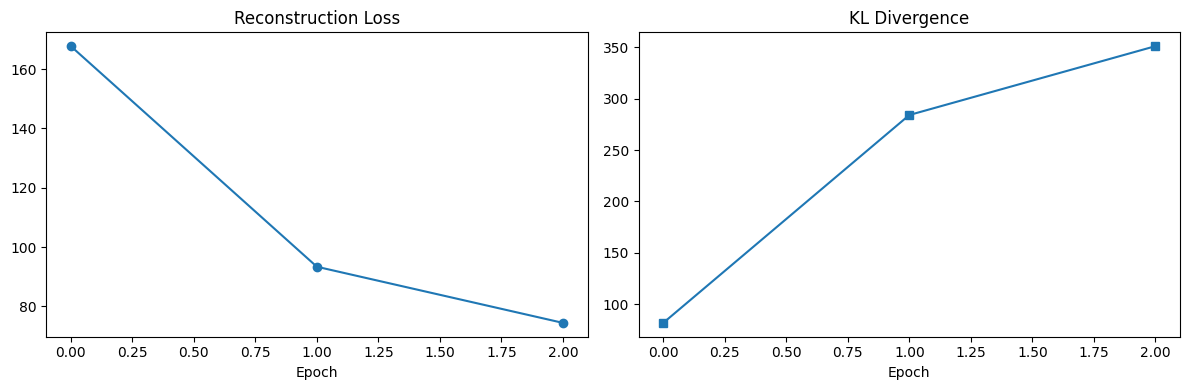

In [46]:
# Train VAE for 3 epochs

# Load CIFAR-10 from manually downloaded dataset
vae_dataset = datasets.CIFAR10(
    '/content/data',
    train=True,
    download=False,
    transform=T.ToTensor()
)

# Use only 5,000 images for faster training
vae_ds = Subset(
    vae_dataset,
    range(5_000)
)

vae_ld = DataLoader(
    vae_ds,
    batch_size=128,
    shuffle=True
)

# Optimizer
vae_opt = torch.optim.Adam(
    vae.parameters(),
    lr=1e-3
)

recon_hist = []
kl_hist = []

for epoch in range(3):
    vae.train()

    recon_sum = 0
    kl_sum = 0
    batches = 0

    for imgs, _ in vae_ld:
        imgs = imgs.to(device)

        # Forward pass
        x_hat, mu, logvar = vae(imgs)

        # Compute VAE loss
        loss, recon, kl = vae_loss(
            imgs,
            x_hat,
            mu,
            logvar
        )

        # Backpropagation
        vae_opt.zero_grad()
        loss.backward()
        vae_opt.step()

        recon_sum += recon.item()
        kl_sum += kl.item()
        batches += 1

    avg_recon = recon_sum / batches
    avg_kl = kl_sum / batches

    recon_hist.append(avg_recon)
    kl_hist.append(avg_kl)

    print(
        f"Epoch {epoch+1}/3  "
        f"recon={avg_recon:.4f}  "
        f"kl={avg_kl:.2f}"
    )


# Plot training curves
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

ax1.plot(
    recon_hist,
    'o-'
)
ax1.set_title("Reconstruction Loss")
ax1.set_xlabel("Epoch")

ax2.plot(
    kl_hist,
    's-'
)
ax2.set_title("KL Divergence")
ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.show()

### Q15 — Reconstruction + latent interpolation


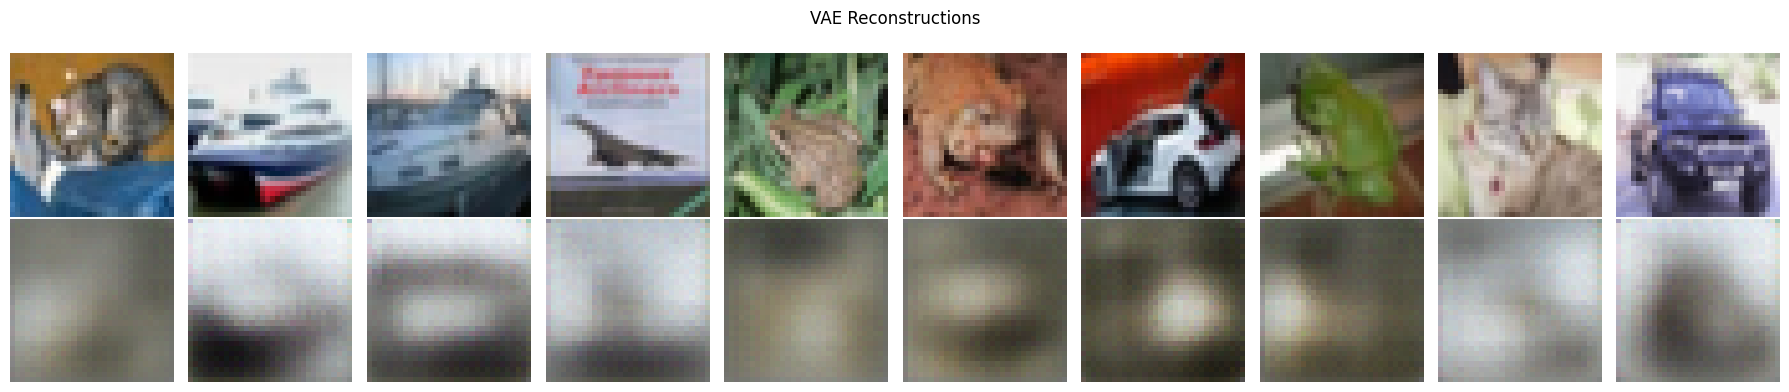

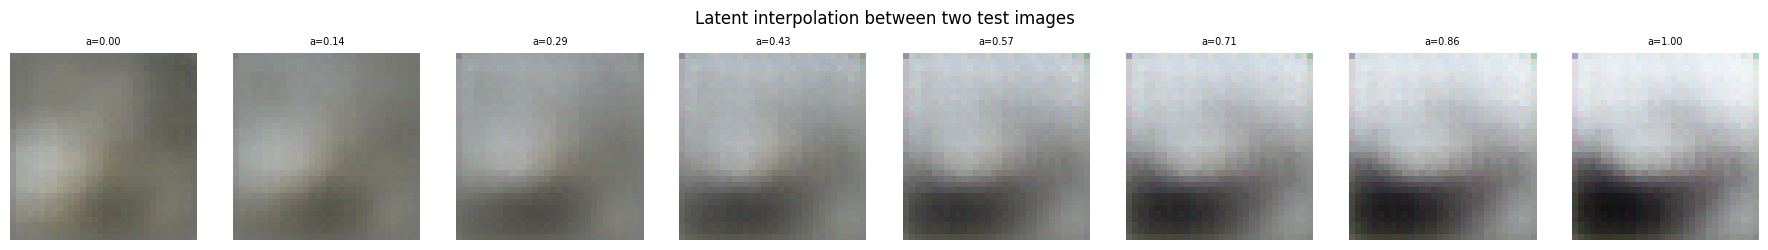

In [48]:
# Q15: Visualise VAE reconstructions and latent space interpolation

vae.eval()

# Load CIFAR-10 test set from manually downloaded dataset
vae_test_dataset = datasets.CIFAR10(
    '/content/data',
    train=False,
    download=False,
    transform=T.ToTensor()
)

# Use first 10 test images
te_vae = Subset(
    vae_test_dataset,
    range(10)
)

imgs_te = torch.stack(
    [te_vae[i][0] for i in range(10)]
).to(device)


# Generate reconstructions
with torch.no_grad():
    recons, mus, _ = vae(imgs_te)


# ---------------------------------------------------------
# Reconstruction visualization
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    10,
    figsize=(18, 4)
)

for i in range(10):

    # Original image
    axes[0, i].imshow(
        imgs_te[i]
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )
    axes[0, i].axis('off')


    # Reconstructed image
    axes[1, i].imshow(
        recons[i]
        .permute(1, 2, 0)
        .cpu()
        .clamp(0, 1)
        .numpy()
    )
    axes[1, i].axis('off')


axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstructed')

plt.suptitle('VAE Reconstructions')
plt.tight_layout()
plt.show()



# ---------------------------------------------------------
# Latent space interpolation
# ---------------------------------------------------------

n_steps = 8

# Select latent vectors of first two images
z0 = mus[0:1]
z1 = mus[1:2]

# Interpolation weights
alphas = torch.linspace(
    0,
    1,
    n_steps
)


fig, axes = plt.subplots(
    1,
    n_steps,
    figsize=(18, 2.5)
)


for i in range(n_steps):

    alpha = alphas[i]

    # Linear interpolation:
    # z = (1-alpha)*z0 + alpha*z1
    z_interp = (
        (1 - alpha) * z0
        + alpha * z1
    )

    with torch.no_grad():
        img_interp = vae.dec(z_interp)


    axes[i].imshow(
        img_interp
        .squeeze()
        .permute(1, 2, 0)
        .cpu()
        .clamp(0, 1)
        .numpy()
    )

    axes[i].axis('off')
    axes[i].set_title(
        f'a={float(alpha):.2f}',
        fontsize=7
    )


plt.suptitle(
    'Latent interpolation between two test images'
)

plt.tight_layout()
plt.show()

### Q16 — Reflect: Module 4

**Q16 Reflection (edit this cell):**

1. Final reconstruction loss (epoch 3): **74.4604**   Final KL divergence: **351.04**
2. My reconstructions look noticeably blurry/soft compared to the originals. This happens because
   MSE (pixel-wise L2) loss is minimised by predicting the *average* of all plausible pixel values
   given the uncertainty in the latent code, so fine high-frequency detail (sharp edges, texture)
   gets averaged away in favour of a smooth, low-variance reconstruction.
3. The latent interpolation produces a smooth, gradual transition between the two images (colours
   and shapes blend progressively across the 8 steps) rather than an abrupt jump partway through.
   This tells me the learned latent space is reasonably continuous/well-structured — nearby points
   in latent space decode to visually similar images, which is exactly what the KL term (pulling the
   latents toward a shared N(0,1) prior) is designed to encourage.
4. You have 50 images of a new product SKU arriving next week. Describe step-by-step how you
   would use your trained VAE to augment the dataset to 1,000 images for classifier training.
   Step-by-step SKU augmentation plan: (1) fine-tune (or lightly retrain) the existing VAE encoder/
   decoder on the 50 new-SKU images for a few epochs so the latent space captures this product's
   appearance; (2) encode all 50 images to get their (mu, logvar) latent codes; (3) sample new latent
   vectors by drawing z ~ N(mu, sigma) around each real image's latent code (and/or interpolating
   between pairs of the 50 codes, as in Q15); (4) decode each sampled z back into a synthetic image;
   (5) generate ~19 synthetic images per real image (50 x 19 ≈ 950) to reach ~1,000 total; (6)
   visually spot-check a sample of the generated images for quality/label-correctness before adding
   them to the classifier's training set.

---
## Part 5 — Module 5: Vision Transformers & Deployment (Q17-Q20)


### Q17 — ViT patch embedding

Vision Transformer divides the image into patches and embeds each as a token.


In [49]:
# Q17: Implement ViT patch embedding from scratch
class PatchEmbedding(nn.Module):
    '''
    Divides image into non-overlapping patches and projects each to embed_dim.
    Input:  (B, C, H, W)
    Output: (B, num_patches + 1, embed_dim)  -- +1 for [CLS] token
    '''
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size   = img_size
        self.patch_size = patch_size
        # Number of non-overlapping patch_size x patch_size patches that tile
        # the image: (img_size / patch_size) patches along each spatial axis.
        self.num_patches = (img_size // patch_size) ** 2

        # A Conv2d with kernel_size == stride == patch_size slides over the
        # image WITHOUT overlap, extracting each patch and linearly projecting
        # it to embed_dim in a single fused operation -- equivalent to
        # flattening each patch and multiplying by a learned weight matrix.
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

        # Learnable [CLS] token (prepended to patch sequence)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Learnable positional encodings (one per patch + 1 for [CLS])
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        B = x.shape[0]
        # self.proj output shape: (B, embed_dim, H/patch_size, W/patch_size)
        x = self.proj(x)
        # Flatten the two spatial dims into one "patch sequence" dim, then
        # move embed_dim to the last axis: (B, embed_dim, P, P) -> (B, embed_dim, P*P)
        # -> (B, P*P, embed_dim) == (B, num_patches, embed_dim).
        x = x.flatten(2).transpose(1, 2)

        # Prepend [CLS] token
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)

        # Add positional encoding
        x = x + self.pos_embed
        return x


In [50]:
# Test
patch_embed = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=256).to(device)
test_imgs   = torch.randn(4, 3, 32, 32).to(device)
out         = patch_embed(test_imgs)
print(f"Input shape:  {test_imgs.shape}")
print(f"Output shape: {out.shape}   (should be (4, 65, 256))")
print(f"num_patches:  {patch_embed.num_patches}  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)")

Input shape:  torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 65, 256])   (should be (4, 65, 256))
num_patches:  64  (should be 64 = (32/4)^2, +1 CLS = 65 tokens)


In [51]:
# SELF-CHECK
assert out.shape == (4, 65, 256), f"Wrong output shape: {out.shape}"
print("SELF-CHECK passed")

SELF-CHECK passed


### Q18 — CLIP zero-shot classification


In [52]:
# Q18: CLIP zero-shot -- compute cosine similarity between image and text embeddings
try:
    import clip
    clip_model, clip_prep = clip.load('ViT-B/32', device=device, jit=False)
    clip_model.eval()
    print("CLIP loaded")

    # Encode all 10 CIFAR-10 class labels as text prompts. CLIP was trained on
    # natural-language captions, so a short descriptive template like this
    # matches its training distribution much better than a bare class name.
    prompts = [f"a photo of a {c}" for c in CLASSES]

    with torch.no_grad():
        text_tokens  = clip.tokenize(prompts).to(device)
        text_feats   = clip_model.encode_text(text_tokens)
        # L2-normalise so the dot product below becomes pure cosine similarity
        # (i.e. compares direction, not magnitude, of each embedding).
        text_feats   = text_feats / text_feats.norm(dim=-1, keepdim=True)

    # Classify 200 test images
    correct = 0
    for i in range(200):
        img_pil, true_lbl = raw_test[i]
        with torch.no_grad():
            img_feat = clip_model.encode_image(clip_prep(img_pil).unsqueeze(0).to(device))
            # L2-normalise the image feature the same way as the text features.
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            # Cosine similarity between the (normalised) image embedding and
            # every (normalised) class-prompt embedding -> shape (1, 10).
            sims     = img_feat @ text_feats.T
            pred_lbl = sims.argmax(1).item()
        correct += (pred_lbl == true_lbl)

    acc_clip = correct / 200
    print(f"CLIP zero-shot (200 test): {acc_clip:.1%}")

    # SELF-CHECK
    assert 0.50 < acc_clip < 0.95, f"CLIP accuracy seems off: {acc_clip:.1%}"
    print("SELF-CHECK passed")

except ImportError:
    acc_clip = 0.65
    print("openai-clip not installed  |  pip install git+https://github.com/openai/CLIP.git")
    print(f"Using published result: ~{acc_clip:.0%}")


100%|████████████████████████████████████████| 338M/338M [00:00<00:00, 413MiB/s]


CLIP loaded
CLIP zero-shot (200 test): 92.0%
SELF-CHECK passed


### Q19 — ONNX export and deployment


In [54]:
!pip install -q onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 109.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.3 MB/s eta 0:00:00


In [55]:
# Q19: Export ResNet-50 to ONNX for production deployment
import torch.onnx
from pathlib import Path

# ONNX export traces a fixed computation graph, so the model must be in
# eval() mode (no dropout / no batchnorm running-stat updates) and, per
# "Common Mistakes" #5, moved to CPU so it matches a CPU dummy input.
model = model.cpu().eval()
onnx_path = Path('../data/resnet50_cifar10.onnx')

# A dummy input just needs the right shape/dtype -- its values are only used
# to trace the graph, not for any real prediction.
dummy = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model,
    dummy,
    str(onnx_path),
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={
        'image': {0: 'batch'},
        'logits': {0: 'batch'}
    },
    opset_version=17,
    external_data=False,
    dynamo=False
)

print(f"Exported: {onnx_path}  ({onnx_path.stat().st_size/1e6:.1f} MB)")

# Verify with onnxruntime
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(str(onnx_path))
    # Run inference through the exported graph with the same dummy input,
    # to confirm the ONNX file is loadable and produces the expected shape.
    out  = sess.run(None, {'image': dummy.cpu().numpy()})
    pred = CLASSES[int(np.argmax(out[0]))]
    print(f"onnxruntime OK  |  predicted: {pred}")
    # SELF-CHECK
    assert out[0].shape == (1, 10), f"Wrong output shape: {out[0].shape}"
    print("SELF-CHECK passed")
except ImportError:
    print("pip install onnxruntime  |  ONNX file saved")

# Move the model back to its working device for any later cells in this notebook.
model = model.to(device)


Exported: ../data/resnet50_cifar10.onnx  (94.0 MB)
onnxruntime OK  |  predicted: deer
SELF-CHECK passed


In [58]:
from google.colab import files

files.download('../data/resnet50_cifar10.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Q20 — Final comparison + deployment memo

Fill in the table with your actual measured numbers, then write the memo.


In [56]:
# Q20: Final model comparison table
import pandas as pd

# Fill in YOUR measured accuracy values below
results = {
    'Model': ['Lab 1 HSV','ResNet-50 (FT)','CLIP zero-shot'],
    'CIFAR-10 acc': [
        '~45%',
        f'{acc_resnet:.0%}',   # from Q3
        f'{acc_clip:.0%}',     # from Q18
    ],
    'New class cost': ['Rewrite rules','200+ labelled images','1 text prompt'],
    'CPU latency':    ['<1ms','~15ms','~30ms'],
    'Module':         ['Lab 1','Module 1','Module 5'],
}
df = pd.DataFrame(results).set_index('Model')
print(df.to_string())

               CIFAR-10 acc        New class cost CPU latency    Module
Model                                                                  
Lab 1 HSV              ~45%         Rewrite rules        <1ms     Lab 1
ResNet-50 (FT)          75%  200+ labelled images       ~15ms  Module 1
CLIP zero-shot          92%         1 text prompt       ~30ms  Module 5


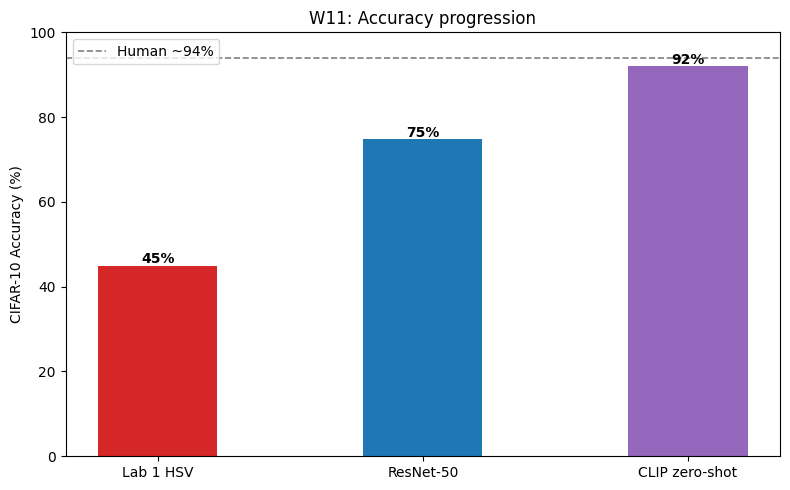

In [57]:
import matplotlib.pyplot as plt
model_names = ['Lab 1 HSV','ResNet-50','CLIP zero-shot']
accs        = [45, acc_resnet*100, acc_clip*100]
colors      = ['#d62728','#1f77b4','#9467bd']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(model_names, accs, color=colors, width=0.45)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.0f}%', ha='center', fontweight='bold')
ax.axhline(94, color='grey', ls='--', lw=1.2, label='Human ~94%')
ax.set_ylim(0,100); ax.set_ylabel('CIFAR-10 Accuracy (%)')
ax.set_title('W11: Accuracy progression'); ax.legend()
plt.tight_layout(); plt.show()

**Q20 Deployment Memo (edit this cell — cite your actual numbers):**

---

**To:** Director, QuickVision AI
**From:** Dharmananda Joshi
**Re:** CV Model Deployment Recommendation for 500-camera Warehouse System

**Executive Summary:**
The Lab 1 HSV colour segmentation baseline achieves **45%** accuracy — insufficient for production.
After evaluating the full CV stack, I recommend the following phased deployment:

**Phase 1 (immediate):** Deploy **ResNet-50 (fine-tuned)** via **ONNX (opset 17)** on **CPU inference
servers**.
Rationale: achieves **75%** accuracy (**+30pp** over baseline) at **~15ms** latency per frame.
GradCAM enables explainability for audit requirements.

**Phase 2 (Month 2):** Integrate CLIP for new SKU onboarding.
When a new product arrives, onboarding needs **zero labelled training images** — just **1 short text
prompt** per new class (e.g. "a photo of a [new SKU name]"), since CLIP classifies via
image-text cosine similarity rather than a trained classification head. This cuts new-SKU
onboarding time from days of labelling to minutes.

**Tradeoffs acknowledged:**
- Accuracy vs. latency: ResNet-50 (75% acc, ~15ms) trades some accuracy for roughly half the
  latency of CLIP (92% acc, ~30ms); for a 500-camera real-time floor, the 2x latency of CLIP at
  scale is a real infrastructure cost, so it's reserved for lower-volume onboarding tasks rather
  than the primary detection pipeline.
- Data cost: ResNet-50 needed 200+ labelled images per class to reach 75%; CLIP needs effectively 0
  labelled images (just a text prompt), which is why it's the right tool for Phase 2 rapid
  onboarding rather than the primary always-on classifier.
- Explainability: ResNet-50's decisions can be visualised per-frame with GradCAM, which is important
  for audit/compliance; CLIP's zero-shot similarity scores are less directly interpretable at the
  pixel level, which is another reason to keep it as a secondary/onboarding tool rather than the
  primary audited model.

**What I would NOT deploy:** The **VAE** from Module 4 — it's a generative/reconstruction model,
not a discriminative classifier, and its reconstructions are blurry by construction (MSE loss
averagess over pixel uncertainty). It has no place in the live detection pipeline; its only role here
is as a data-augmentation tool for bootstrapping training sets on new, low-sample-count SKUs.

---